# OTP specialization and win probability

This notebook estimates whether champion specialization is associated with winning after accounting for matchup strength, rank, lane, side, and champion. The goal is interpretation—not production match prediction.

The current patch sample is provisional. Rerun this notebook after expanding the Riot collection window.

## 1. Imports

If `statsmodels` is unavailable, run `%pip install statsmodels` once and restart the kernel.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

def display_percentages(frame, columns, digits=2, signed=()):
    output = frame.copy()
    for column in columns:
        if column in output:
            sign = '+' if column in signed else ''
            output[column] = output[column].map(
                lambda value: f'{value:{sign}.{digits}%}' if pd.notna(value) else ''
            )
    display(output)

## 2. Load and prepare the modeling sample

The complete parquet remains unchanged. The 50-match matchup cutoff and all transformations happen in memory.

In [2]:
start_dir = Path.cwd().resolve()
search_dirs = [start_dir, *start_dir.parents]
PROJECT_DIR = next(
    (path for path in search_dirs if (path / 'data' / 'processed').exists()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError('Could not find the repository data/processed directory.')

DATA_PATH = PROJECT_DIR / 'data' / 'processed' / 'otp_analysis_16_19.parquet'
raw_df = pd.read_parquet(DATA_PATH)

required = {
    'match_id', 'puuid', 'seed_tier', 'side', 'lane', 'champion', 'win',
    'champion_share', 'raw_matchup_winrate', 'matchup_games',
    'matchup_games_ge_50',
}
missing = required.difference(raw_df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

model_df = (
    raw_df.loc[raw_df['matchup_games_ge_50']].copy()
    .rename(columns={'seed_tier': 'rank', 'champion_share': 'otp_rate'})
)
model_df['win'] = model_df['win'].astype(int)
model_df['otp_rate'] = pd.to_numeric(model_df['otp_rate'], errors='coerce')
model_df['matchup_winrate'] = (
    pd.to_numeric(model_df['raw_matchup_winrate'], errors='coerce') / 100
)

# Scaling makes the coefficients readable.
# One unit of otp_rate_10pp = a 10-percentage-point increase in champion usage.
# One unit of matchup_winrate_1pp = a 1-percentage-point matchup advantage.
model_df['otp_rate_10pp'] = model_df['otp_rate'] * 10
model_df['matchup_winrate_1pp'] = model_df['matchup_winrate'] * 100

model_columns = [
    'match_id', 'puuid', 'win', 'otp_rate', 'otp_rate_10pp',
    'matchup_winrate', 'matchup_winrate_1pp',
    'rank', 'lane', 'side', 'champion',
]
model_df = model_df.loc[:, model_columns].dropna().reset_index(drop=True)

print('Source:', DATA_PATH)
print('Modeling rows:', f'{len(model_df):,}')
print('Unique matches:', f"{model_df['match_id'].nunique():,}")
print('Unique players:', f"{model_df['puuid'].nunique():,}")
display(model_df.head())

Source: /Users/minhho-hoang/Documents/riot_proj/riot-game-prediction/data/processed/otp_analysis_16_19.parquet
Modeling rows: 4,283
Unique matches: 989
Unique players: 1,326


,match_id,puuid,win,otp_rate,otp_rate_10pp,matchup_winrate,matchup_winrate_1pp,rank,lane,side,champion
0,NA1_5649511668,3gNdz4Q0umzJCWX0_Ao1DlXIig2vMov53d7ltMh3PIAjnf...,1,0.3600,3.6000,0.5381,53.8100,challenger,mid,red,TwistedFate
1,NA1_5649511668,By3WaYwajWV2YnZ6W4Vb1arXlLc_4gAOoKpZHGvI6t98Sc...,0,0.2200,2.2000,0.4656,46.5600,grandmaster,mid,blue,AurelionSol
2,NA1_5649511668,GpD59_ThmLRGDxXIAZcaNEvOvILQxC1bZS7sXZJcjoCGai...,1,0.9400,9.4000,0.5371,53.7100,master,top,red,Illaoi
3,NA1_5649511668,LDk1guhzOXvgZh6wXiI1dEPrk-rFAUBvB1A_tzraBbl1ib...,0,0.6200,6.2000,0.4554,45.5400,grandmaster,adc,blue,Syndra
4,NA1_5649511668,Yb_izYdkTe1ekL_67OYEQ__WaInRF-CSqp5uYlpsFbT8zM...,1,0.2400,2.4000,0.4747,47.4700,grandmaster,jungle,red,LeeSin


## 3. Modeling checks

The outcome must be binary, rates must be valid, and each sampled player should appear at most once per match.

In [3]:
assert model_df['win'].isin([0, 1]).all()
assert model_df['otp_rate'].between(0, 1).all()
assert model_df['matchup_winrate'].between(0, 1).all()
assert model_df.duplicated(['match_id', 'puuid']).sum() == 0

audit = pd.Series({
    'player rows': len(model_df),
    'unique matches': model_df['match_id'].nunique(),
    'unique players': model_df['puuid'].nunique(),
    'actual win rate': model_df['win'].mean(),
    'average OTP rate': model_df['otp_rate'].mean(),
    'average raw matchup WR': model_df['matchup_winrate'].mean(),
})
display(audit.to_frame('value'))

,value
player rows,"4,283.0000"
unique matches,989.0000
unique players,"1,326.0000"
actual win rate,0.4961
average OTP rate,0.2978
average raw matchup WR,0.5118


## 4. Primary models: linear probability models

A linear probability model makes the OTP coefficient directly interpretable as a change in win probability. Standard errors are clustered by both match and player because multiple sampled observations can share a match and each player can appear repeatedly.

- **Model 0:** unadjusted OTP association
- **Model 1:** adds matchup, rank, lane, and side
- **Model 2:** additionally compares players while controlling for champion

In [4]:
def two_way_cluster_codes(data, retained_index):
    # statsmodels' two-way cluster covariance requires numeric, aligned group IDs.
    retained = data.loc[retained_index, ['match_id', 'puuid']]
    if retained.isna().any().any():
        raise ValueError('Both cluster identifiers must be nonmissing.')
    if retained.nunique().min() < 2:
        raise ValueError('Two-way clustering needs at least two matches and players.')
    return np.column_stack([
        pd.factorize(retained[column], sort=False)[0]
        for column in ['match_id', 'puuid']
    ])


def fit_lpm(formula, data):
    model = smf.ols(formula, data=data)
    # Patsy may discard rows; align the cluster IDs with the observations it keeps.
    groups = two_way_cluster_codes(data, model.data.row_labels)
    return model.fit(
        cov_type='cluster',
        cov_kwds={'groups': groups, 'use_correction': True},
    )


formulas = {
    'Model 0: OTP only': 'win ~ otp_rate_10pp',
    'Model 1: core controls': (
        'win ~ otp_rate_10pp + matchup_winrate_1pp '
        '+ C(rank) + C(lane) + C(side)'
    ),
    'Model 2: + champion': (
        'win ~ otp_rate_10pp + matchup_winrate_1pp '
        '+ C(rank) + C(lane) + C(side) + C(champion)'
    ),
}

lpm_models = {name: fit_lpm(formula, model_df) for name, formula in formulas.items()}
print('Models fitted with match-and-player-clustered SE:', ', '.join(lpm_models))

Models fitted with match-and-player-clustered SE: Model 0: OTP only, Model 1: core controls, Model 2: + champion


,model,effect_pp_per_10pp_otp,ci_low_pp,ci_high_pp,p_value,rows,r_squared
0,Model 0: OTP only,0.7452,0.2868,1.2036,0.0014,4283,0.0022
1,Model 1: core controls,0.7463,0.2875,1.2050,0.0014,4283,0.0105
2,Model 2: + champion,0.7578,0.2227,1.2929,0.0055,4283,0.0437


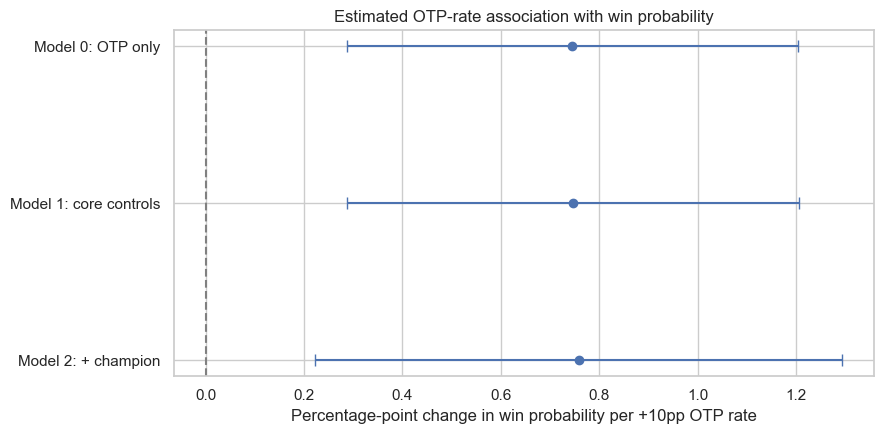

In [5]:
def otp_result_row(name, fitted_model):
    term = 'otp_rate_10pp'
    ci_low, ci_high = fitted_model.conf_int().loc[term]
    return {
        'model': name,
        'effect_pp_per_10pp_otp': fitted_model.params[term] * 100,
        'ci_low_pp': ci_low * 100,
        'ci_high_pp': ci_high * 100,
        'p_value': fitted_model.pvalues[term],
        'rows': int(fitted_model.nobs),
        'r_squared': fitted_model.rsquared,
    }

otp_model_results = pd.DataFrame([
    otp_result_row(name, fitted_model)
    for name, fitted_model in lpm_models.items()
])
display(otp_model_results)

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_table = otp_model_results.iloc[::-1].reset_index(drop=True)
ax.errorbar(
    plot_table['effect_pp_per_10pp_otp'],
    plot_table['model'],
    xerr=[
        plot_table['effect_pp_per_10pp_otp'] - plot_table['ci_low_pp'],
        plot_table['ci_high_pp'] - plot_table['effect_pp_per_10pp_otp'],
    ],
    fmt='o',
    capsize=4,
)
ax.axvline(0, color='gray', linestyle='--')
ax.set(
    title='Estimated OTP-rate association with win probability',
    xlabel='Percentage-point change in win probability per +10pp OTP rate',
    ylabel='',
)
plt.tight_layout()
plt.show()

In [6]:
main_lpm = lpm_models['Model 2: + champion']
effect = main_lpm.params['otp_rate_10pp'] * 100
ci_low, ci_high = main_lpm.conf_int().loc['otp_rate_10pp'] * 100
p_value = main_lpm.pvalues['otp_rate_10pp']
direction = 'increase' if effect >= 0 else 'decrease'

print(
    f'After adjustment, a 10-percentage-point increase in OTP rate is associated '
    f'with a {abs(effect):.2f}-percentage-point {direction} in win probability '
    f'(95% CI: {ci_low:.2f} to {ci_high:.2f}; p={p_value:.4f}).'
)

After adjustment, a 10-percentage-point increase in OTP rate is associated with a 0.76-percentage-point increase in win probability (95% CI: 0.22 to 1.29; p=0.0055).


## 5. Logistic-regression robustness check

Logistic regression respects the 0–1 probability boundary. The code translates its result into the average predicted win-probability change from increasing OTP rate by 10 percentage points, holding other measured variables fixed. Coefficient standard errors use the same match-and-player clustering as the linear model. The linear model remains the primary estimate.

In [7]:
logit_spec = smf.glm(
    formulas['Model 2: + champion'],
    data=model_df,
    family=sm.families.Binomial(),
)
logit_model = logit_spec.fit(
    cov_type='cluster',
    cov_kwds={
        'groups': two_way_cluster_codes(model_df, logit_spec.data.row_labels),
        'use_correction': True,
    },
)

# Compare each eligible row with itself at an OTP rate 10 percentage points higher.
eligible = model_df.loc[model_df['otp_rate'] <= 0.90].copy()
higher_otp = eligible.copy()
higher_otp['otp_rate'] += 0.10
higher_otp['otp_rate_10pp'] += 1
logit_effect_pp = (
    logit_model.predict(higher_otp) - logit_model.predict(eligible)
).mean() * 100

print(
    'Logistic-model average probability change for +10pp OTP rate: '
    f'{logit_effect_pp:+.2f} percentage points'
)
print(
    'Logistic OTP coefficient p-value (match-and-player-clustered): '
    f"{logit_model.pvalues['otp_rate_10pp']:.4f}"
)

Logistic-model average probability change for +10pp OTP rate: +0.76 percentage points
Logistic OTP coefficient p-value (match-and-player-clustered): 0.0055


## 6. Matchup equivalent of the OTP association

The estimated OTP coefficient can be expressed on the same scale as the matchup coefficient, holding champion and the other controls fixed. For a given main-versus-alternative OTP-rate gap, this is a **matchup equivalent**, not a complete champion-switching threshold. Switching champions also changes the champion indicator in Model 2; a champion-specific comparison would need that coefficient difference and credible data on both possible picks. This is an observational, population-level association.

Approximate 95% intervals use the delta method and the joint, two-way-clustered covariance of the OTP and matchup coefficients. A ratio is unstable if the matchup coefficient is not clearly positive, so the notebook withholds it in that case.

In [8]:
otp_term = 'otp_rate_10pp'
matchup_term = 'matchup_winrate_1pp'
otp_coef = main_lpm.params[otp_term]
matchup_coef = main_lpm.params[matchup_term]
matchup_ci_low = main_lpm.conf_int().loc[matchup_term, 0]

if matchup_coef <= 0 or matchup_ci_low <= 0:
    matchup_ratio = np.nan
    matchup_ratio_se = np.nan
    print(
        'Matchup equivalent withheld: the adjusted matchup coefficient has '
        'not been estimated as clearly positive. Report both coefficients instead.'
    )
else:
    matchup_ratio = otp_coef / matchup_coef
    joint_cov = main_lpm.cov_params().loc[
        [otp_term, matchup_term], [otp_term, matchup_term]
    ].to_numpy()
    gradient = np.array([1 / matchup_coef, -otp_coef / matchup_coef**2])
    ratio_variance = float(gradient @ joint_cov @ gradient)
    if ratio_variance < -1e-12:
        raise ValueError('Two-way cluster covariance yielded a negative ratio variance.')
    matchup_ratio_se = np.sqrt(max(ratio_variance, 0.0))


def matchup_equivalent_interval(main_otp_rate, alternative_otp_rate):
    if not (0 <= alternative_otp_rate <= main_otp_rate <= 1):
        raise ValueError('Expected shares between 0 and 1, with main >= alternative.')
    if main_otp_rate + alternative_otp_rate > 1 + 1e-12:
        raise ValueError('Shares for one player cannot sum to more than 100%.')
    gap_in_10pp_units = (main_otp_rate - alternative_otp_rate) * 10
    if not np.isfinite(matchup_ratio):
        return pd.Series({'matchup_equivalent_pp': np.nan,
                          'ci_low_pp': np.nan, 'ci_high_pp': np.nan})
    estimate = gap_in_10pp_units * matchup_ratio
    margin = 1.96 * gap_in_10pp_units * matchup_ratio_se
    return pd.Series({'matchup_equivalent_pp': estimate,
                      'ci_low_pp': estimate - margin, 'ci_high_pp': estimate + margin})


example_pairs = pd.DataFrame({
    # Feasible shares for the same player: each pair sums to at most 100%.
    'main_otp_rate': [0.60, 0.70, 0.80, 0.90],
    'alternative_otp_rate': [0.40, 0.30, 0.20, 0.10],
})
example_pairs['otp_rate_gap'] = (
    example_pairs['main_otp_rate'] - example_pairs['alternative_otp_rate']
)
example_pairs = pd.concat([
    example_pairs,
    example_pairs.apply(
        lambda row: matchup_equivalent_interval(
            row['main_otp_rate'], row['alternative_otp_rate']
        ),
        axis=1,
    ),
], axis=1)
display_percentages(
    example_pairs,
    ['main_otp_rate', 'alternative_otp_rate', 'otp_rate_gap'],
    digits=0,
)
print('Matchup equivalent and approximate 95% interval are in percentage points.')

,main_otp_rate,alternative_otp_rate,otp_rate_gap,matchup_equivalent_pp,ci_low_pp,ci_high_pp
0,60%,40%,20%,1.8490,0.0851,3.6129
1,70%,30%,40%,3.6980,0.1702,7.2258
2,80%,20%,60%,5.5470,0.2553,10.8388
3,90%,10%,80%,7.3961,0.3405,14.4517


Matchup equivalent and approximate 95% interval are in percentage points.


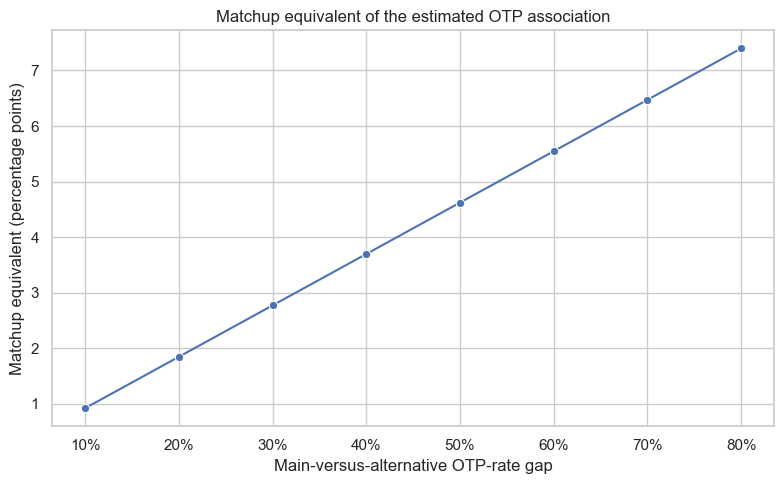

In [9]:
otp_gaps = np.arange(0.10, 0.81, 0.10)
matchup_equivalent_curve = pd.DataFrame({
    'otp_rate_gap': otp_gaps,
    'matchup_equivalent_pp': [
        matchup_equivalent_interval(gap, 0)['matchup_equivalent_pp']
        for gap in otp_gaps
    ],
})

if matchup_equivalent_curve['matchup_equivalent_pp'].notna().any():
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(
        data=matchup_equivalent_curve,
        x='otp_rate_gap',
        y='matchup_equivalent_pp',
        marker='o',
        ax=ax,
    )
    ax.xaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
    ax.set(
        title='Matchup equivalent of the estimated OTP association',
        xlabel='Main-versus-alternative OTP-rate gap',
        ylabel='Matchup equivalent (percentage points)',
    )
    plt.tight_layout()
    plt.show()

## 7. Does the OTP association differ by rank or lane?

Each interaction model starts from Model 2 and allows the OTP slope to vary by one group. A joint Wald test asks whether those slopes differ across the group's categories, using match-and-player-clustered uncertainty. Separate subgroup estimates below offer descriptive context; an interval crossing zero in one subgroup does not test whether two subgroups differ.

In [10]:
def joint_otp_interaction_test(group):
    other_group = 'rank' if group == 'lane' else 'lane'
    formula = (
        f'win ~ otp_rate_10pp * C({group}) + matchup_winrate_1pp '
        f'+ C({other_group}) + C(side) + C(champion)'
    )
    fitted = fit_lpm(formula, model_df)
    interaction_terms = [
        term for term in fitted.params.index
        if term.startswith(f'otp_rate_10pp:C({group})[')
    ]
    if not interaction_terms:
        raise ValueError(f'No OTP-by-{group} interaction terms were estimated.')
    restriction = np.zeros((len(interaction_terms), len(fitted.params)))
    for i, term in enumerate(interaction_terms):
        restriction[i, fitted.params.index.get_loc(term)] = 1
    # Joint null: all nonreference OTP slopes match the reference group's slope.
    joint_test = fitted.wald_test(restriction, use_f=False, scalar=True)
    return {
        'group': group,
        'tested_interactions': len(interaction_terms),
        'wald_chi2': float(joint_test.statistic),
        'p_value': float(joint_test.pvalue),
        'rows': int(fitted.nobs),
    }


interaction_results = pd.DataFrame([
    joint_otp_interaction_test('lane'),
    joint_otp_interaction_test('rank'),
])
display(interaction_results)

,group,tested_interactions,wald_chi2,p_value,rows
0,lane,4,1.6685,0.7964,4283
1,rank,2,1.0996,0.5771,4283


In [11]:
def subgroup_effects(data, group_column, group_values):
    rows = []
    for value in group_values:
        subset = data.loc[data[group_column] == value].copy()
        if len(subset) < 100:
            continue

        remaining_group = 'lane' if group_column == 'rank' else 'rank'
        formula = (
            'win ~ otp_rate_10pp + matchup_winrate_1pp '
            f'+ C({remaining_group}) + C(side) + C(champion)'
        )
        fitted = fit_lpm(formula, subset)
        ci_low, ci_high = fitted.conf_int().loc['otp_rate_10pp']
        rows.append({
            group_column: value,
            'player_rows': len(subset),
            'unique_players': subset['puuid'].nunique(),
            'effect_pp_per_10pp_otp': fitted.params['otp_rate_10pp'] * 100,
            'ci_low_pp': ci_low * 100,
            'ci_high_pp': ci_high * 100,
            'p_value': fitted.pvalues['otp_rate_10pp'],
        })
    return pd.DataFrame(rows)

rank_order = ['master', 'grandmaster', 'challenger']
lane_order = ['top', 'jungle', 'mid', 'adc', 'support']
rank_effects = subgroup_effects(model_df, 'rank', rank_order)
lane_effects = subgroup_effects(model_df, 'lane', lane_order)

print('By rank')
display(rank_effects)
print('By lane')
display(lane_effects)

By rank


,rank,player_rows,unique_players,effect_pp_per_10pp_otp,ci_low_pp,ci_high_pp,p_value
0,master,1215,586,0.4930,-0.6427,1.6286,0.3949
1,grandmaster,1858,494,1.0543,0.1814,1.9273,0.0179
2,challenger,1210,246,0.6597,-0.9259,2.2453,0.4148


By lane


,lane,player_rows,unique_players,effect_pp_per_10pp_otp,ci_low_pp,ci_high_pp,p_value
0,top,756,376,1.3602,0.1642,2.5561,0.0258
1,jungle,835,344,1.0840,-0.1251,2.2931,0.0789
2,mid,918,408,1.0133,-0.1312,2.1577,0.0827
3,adc,889,374,1.1019,-0.3878,2.5916,0.1471
4,support,885,404,-0.0021,-1.1992,1.1950,0.9973


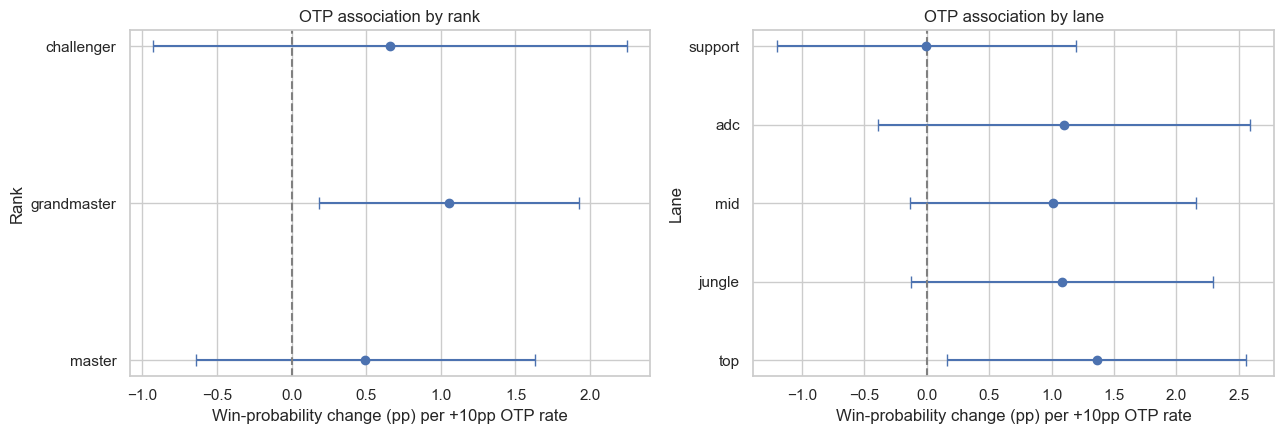

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for table, label, axis in [
    (rank_effects, 'rank', axes[0]),
    (lane_effects, 'lane', axes[1]),
]:
    axis.errorbar(
        table['effect_pp_per_10pp_otp'],
        table[label],
        xerr=[
            table['effect_pp_per_10pp_otp'] - table['ci_low_pp'],
            table['ci_high_pp'] - table['effect_pp_per_10pp_otp'],
        ],
        fmt='o',
        capsize=4,
    )
    axis.axvline(0, color='gray', linestyle='--')
    axis.set(
        title=f'OTP association by {label}',
        xlabel='Win-probability change (pp) per +10pp OTP rate',
        ylabel=label.title(),
    )
plt.tight_layout()
plt.show()

In [13]:
print(
    f"OTP effect: {main_lpm.params['otp_rate_10pp'] * 100:.3f} pp "
    f"actual win probability per +10pp OTP rate"
)

print(
    f"Matchup effect: {main_lpm.params['matchup_winrate_1pp'] * 100:.3f} pp "
    f"actual win probability per +1pp baseline matchup WR"
)

print(
    f"Matchup-equivalent ratio: "
    f"{main_lpm.params['otp_rate_10pp'] / main_lpm.params['matchup_winrate_1pp']:.3f} "
    f"pp baseline matchup WR per +10pp OTP rate"
)

OTP effect: 0.758 pp actual win probability per +10pp OTP rate
Matchup effect: 0.820 pp actual win probability per +1pp baseline matchup WR
Matchup-equivalent ratio: 0.925 pp baseline matchup WR per +10pp OTP rate


## Interpretation rules

1. **Use Model 2 as the main adjusted estimate.**  
   Use Model 0 only as the unadjusted comparison. Model 2 controls for matchup win rate, rank, lane, side, and champion.

2. **Interpret the OTP estimate as an association, not a causal effect.**  
   Even after adjustment, unmeasured differences between players or games may remain.

3. **Account for repeated observations.**  
   Inference is clustered by both `match_id` and `puuid` because multiple sampled players can appear in the same match and the same player can appear in multiple matches.

4. **Interpret the main coefficient per 10 percentage points of specialization.**  
   A +10pp increase in previous-50 champion share is associated with about a **+0.76 percentage-point increase in win probability** in Model 2. The 95% CI is approximately **+0.22 to +1.29 percentage points**.

5. **Do not use subgroup estimates alone to claim that the OTP effect differs by lane or rank.**  
   Use the joint interaction tests. In the current sample, there is no statistically detectable difference in the OTP association across lanes or ranks.

6. **`otp_rate` is strictly pre-game.**  
   It is calculated from the player's **50 completed ranked Solo/Duo games before the focal match**. The current game and future games are never included.

7. **Treat the matchup-equivalent calculation as an approximate interpretation, not a literal champion-switch rule.**  
   It compares the estimated OTP coefficient with the matchup-win-rate coefficient while holding the modeled variables fixed. Actually switching champions changes other factors as well.

8. **Treat the current estimates as patch-specific and observational.**  
   They describe this Patch 16.19 Master+ sample and should not automatically be generalized to other patches, ranks, or player populations.